In [4]:
import os
import sys
sys.path.insert(0, os.path.abspath("../../"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from pathlib import Path

In [5]:
root_dir = Path("../../").resolve()
print(f"Root directory:\n{root_dir}")

Root directory:
/home/hgkahng/Workspaces/soft-prompt


In [6]:
result_dir = root_dir / "results_margin"
print(*os.listdir(result_dir), sep="\n")

SST_margin_perf.pdf
tab_binary_with_margin_filtering_cot_std.csv
tab_binary_with_margin_filtering_cot_mean.csv
tab_binary_with_margin_filtering_mean.csv
IMDb_margin_perf.pdf
tab_binary_with_margin_filtering_std.csv
SUBJ_margin_perf.pdf


## 1. Without CoT (base version)

In [7]:
df1 = pd.read_csv(result_dir / "tab_binary_with_margin_filtering_mean.csv")
df1['CoT'] = "No"

df2 = pd.read_csv(result_dir / "tab_binary_with_margin_filtering_cot_mean.csv")
df2['CoT'] = "Yes"
df = pd.concat([df1, df2], axis=0, ignore_index=True)
display(df)

,Data,Size,Margin_0.00,Margin_0.05,Margin_0.10,Margin_0.15,Margin_0.20,Margin_0.25,Margin_0.30,CoT
0,IMDb,1%,75.1,76.6,76.5,80.6,86.9,89.8,90.4,No
1,IMDb,5%,76.1,74.4,74.7,78.7,85.0,89.8,90.4,No
2,IMDb,10%,76.2,74.5,75.5,78.0,84.8,89.5,90.4,No
3,IMDb,25%,77.2,74.7,76.2,77.9,81.0,87.8,90.1,No
4,IMDb,50%,77.1,74.8,76.1,78.0,85.7,89.9,90.2,No
5,IMDb,100%,76.6,75.1,75.9,78.1,84.9,89.3,90.3,No
6,SST,1%,68.9,68.9,70.1,72.3,73.9,73.4,75.4,No
7,SST,5%,70.3,70.3,71.3,72.3,77.4,77.4,77.1,No
8,SST,10%,71.1,70.1,71.5,73.7,77.5,79.1,77.6,No
9,SST,25%,72.4,71.1,73.6,73.8,78.4,81.4,78.0,No


In [8]:
import re

def parse_column_name(colname: str) -> str:
    pattern = 'margin_'
    if colname.lower().startswith(pattern):
        return re.sub(pattern, '', colname.lower())
    return colname

In [9]:
df.columns = [parse_column_name(c) for c in df.columns]
display(df)

,Data,Size,0.00,0.05,0.10,0.15,0.20,0.25,0.30,CoT
0,IMDb,1%,75.1,76.6,76.5,80.6,86.9,89.8,90.4,No
1,IMDb,5%,76.1,74.4,74.7,78.7,85.0,89.8,90.4,No
2,IMDb,10%,76.2,74.5,75.5,78.0,84.8,89.5,90.4,No
3,IMDb,25%,77.2,74.7,76.2,77.9,81.0,87.8,90.1,No
4,IMDb,50%,77.1,74.8,76.1,78.0,85.7,89.9,90.2,No
5,IMDb,100%,76.6,75.1,75.9,78.1,84.9,89.3,90.3,No
6,SST,1%,68.9,68.9,70.1,72.3,73.9,73.4,75.4,No
7,SST,5%,70.3,70.3,71.3,72.3,77.4,77.4,77.1,No
8,SST,10%,71.1,70.1,71.5,73.7,77.5,79.1,77.6,No
9,SST,25%,72.4,71.1,73.6,73.8,78.4,81.4,78.0,No


In [10]:
# def percent_to_float(percent: str) -> float:
#     return float(percent.replace('%', 'e-2'))

# df['Size'] = df['Size'].apply(percent_to_float)
# display(df)

In [11]:
id_cols = ['Data', 'Size', 'CoT']
value_cols = [c for c in df.columns if c not in id_cols]

df_melted = pd.melt(
    frame=df,
    id_vars=id_cols,
    value_vars=value_cols,
    var_name='Margin',
    value_name='Accuracy'
)

display(df_melted)

,Data,Size,CoT,Margin,Accuracy
0,IMDb,1%,No,0.00,75.1
1,IMDb,5%,No,0.00,76.1
2,IMDb,10%,No,0.00,76.2
3,IMDb,25%,No,0.00,77.2
4,IMDb,50%,No,0.00,77.1
...,...,...,...,...,...
247,SUBJ,5%,Yes,0.30,79.0
248,SUBJ,10%,Yes,0.30,78.9
249,SUBJ,25%,Yes,0.30,79.4
250,SUBJ,50%,Yes,0.30,79.2


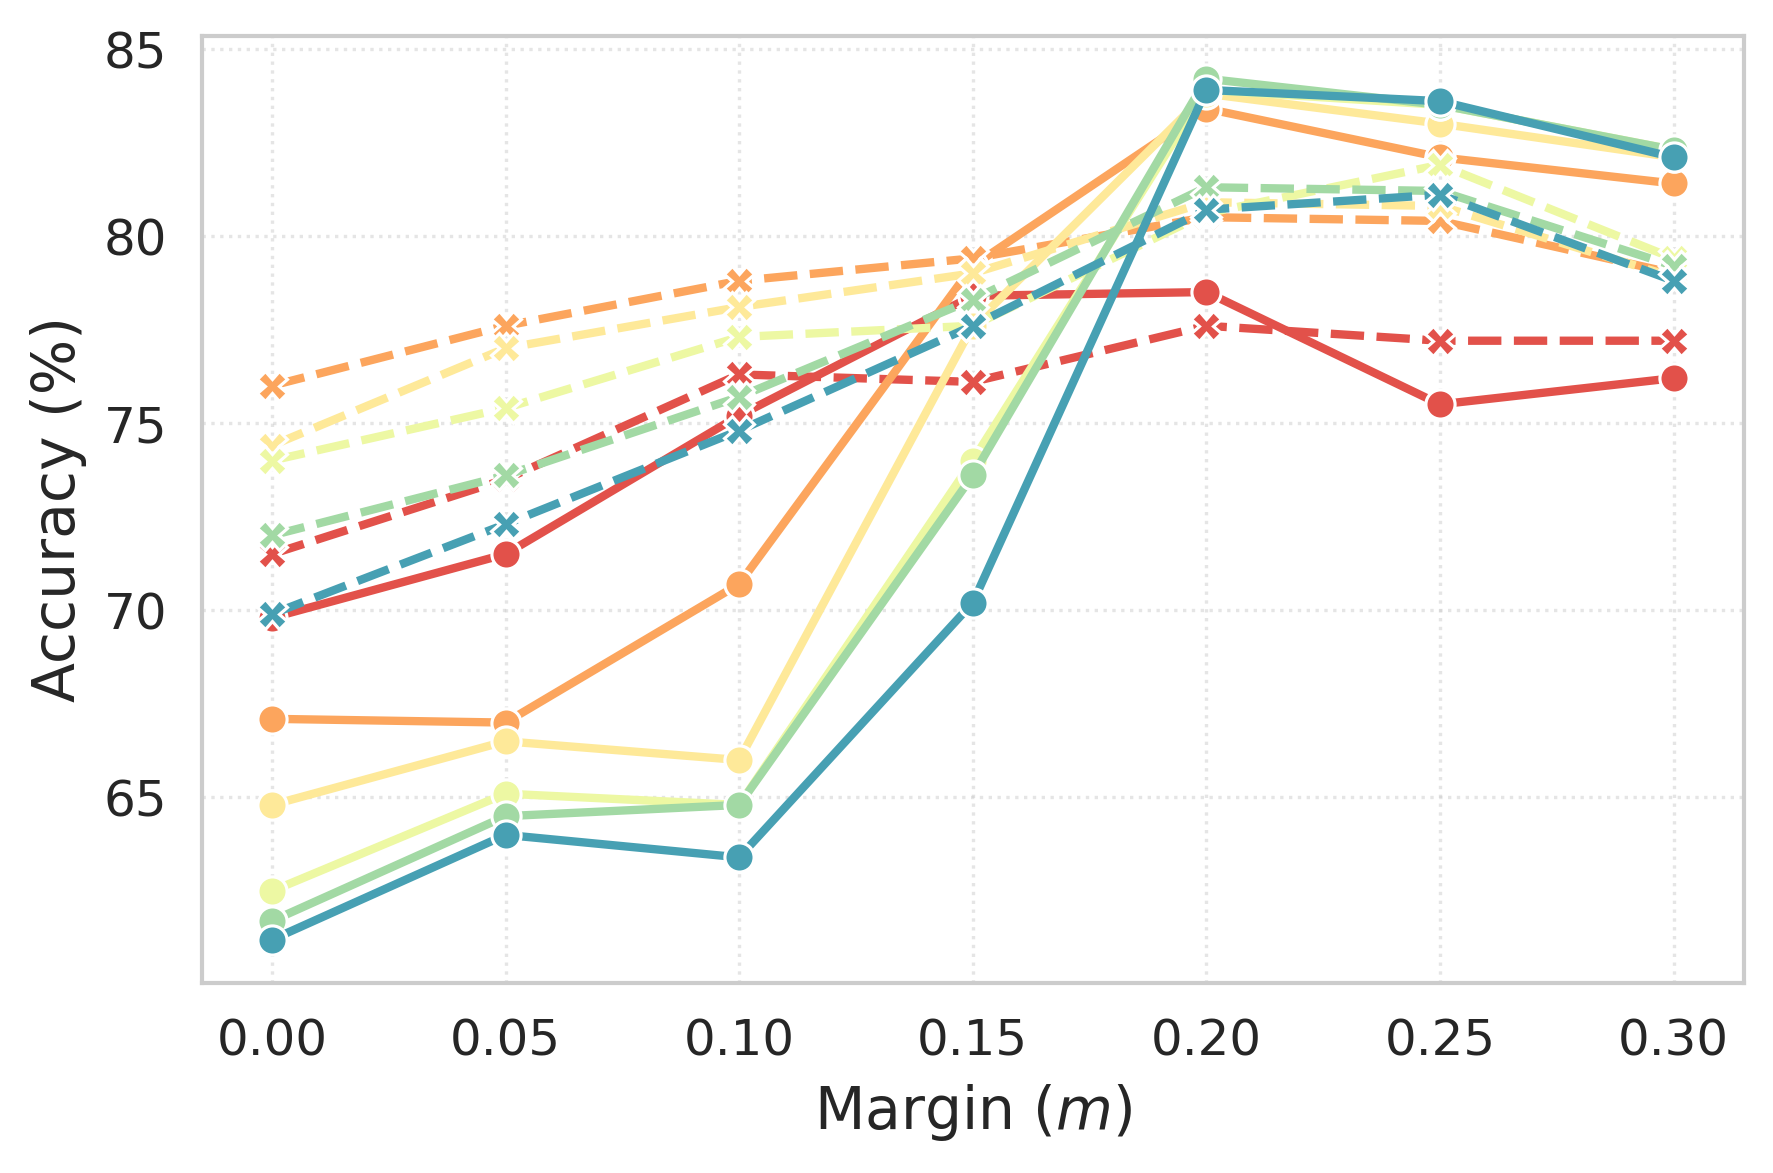

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=300)

data_str = 'SUBJ'; assert data_str in ('IMDb', 'SUBJ', 'SST')
mask = df_melted['Data'] == data_str
sns.set_theme(style="whitegrid", context="paper")
custom_palette = sns.color_palette("Spectral", n_colors=df_melted['Size'].nunique())
sns.lineplot(data=df_melted.loc[mask, :],
             x='Margin', y='Accuracy',
             hue='Size', style='CoT', dashes=True, markers=True,
             palette=custom_palette,  # rocket, mako, cubehelix, Spectral, viridis
             linewidth=2,
             markersize=7,
             ax=ax
             )
# ax.set_title(f"Effect of margin-based filtering (Data:{data_str})")
ax.legend(fontsize=9, title_fontsize=11)
if data_str != "IMDb":
    ax.get_legend().remove()
ax.grid(True, alpha=0.5, linestyle=':')
ax.set_xlabel("Margin ($m$)", fontsize=14)
ax.set_ylabel("Accuracy (%)", fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()
plt.show(fig)

# optionally save figure
save_path = result_dir / f"{data_str}_margin_perf.pdf"
fig.savefig(save_path, dpi=300, bbox_inches='tight')

In [19]:
data = "IMDb"; assert data in ('IMDb', 'SST', 'SUBJ')
df_sub = df[df['Data'] == data].copy()
display(df_sub)

,Data,Size,0.00,0.05,0.10,0.15,0.20,0.25,0.30
0,IMDb,0.01,75.1,76.6,76.5,80.6,86.9,89.8,90.4
1,IMDb,0.05,76.1,74.4,74.7,78.7,85.0,89.8,90.4
2,IMDb,0.10,76.2,74.5,75.5,78.0,84.8,89.5,90.4
3,IMDb,0.25,77.2,74.7,76.2,77.9,81.0,87.8,90.1
4,IMDb,0.50,77.1,74.8,76.1,78.0,85.7,89.9,90.2
5,IMDb,1.00,76.6,75.1,75.9,78.1,84.9,89.3,90.3


0.995